In [43]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

from pyproj import Transformer


In [44]:
import folium

In [45]:
import UBNA_localize_process_GCC__20250505 as localize

In [46]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),


In [47]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [48]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [49]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 19, 0, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_028/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_109/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_057/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_114/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_053/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_026/20260604_190000.WAV'),
 PosixPath

In [50]:
A1_ground_truth_latlon = [47 + (39.3437 / 60), -(122 + (17.8028 / 60))]
A4_ground_truth_latlon = [47 + (39.3243 / 60), -(122 + (17.8002 / 60))]
A7_ground_truth_latlon = [47 + (39.3061 / 60), -(122 + (17.8012 / 60))]

GROUND_TRUTH_LOCS = {'STF_026': A1_ground_truth_latlon, 'STF_028' : A1_ground_truth_latlon,
                     'STF_057': A4_ground_truth_latlon, 'STF_109': A4_ground_truth_latlon,
                     'STF_114': A7_ground_truth_latlon, 'STF_053': A7_ground_truth_latlon}
GROUND_TRUTH_LOCS

{'STF_026': [47.655728333333336, -122.29671333333333],
 'STF_028': [47.655728333333336, -122.29671333333333],
 'STF_057': [47.655405, -122.29667],
 'STF_109': [47.655405, -122.29667],
 'STF_114': [47.65510166666667, -122.29668666666667],
 'STF_053': [47.65510166666667, -122.29668666666667]}

In [51]:
IND_OF_SELECTED_CHANNEL = 2
SOUND_SPEED_AIR = 343

NUM_NONREFCHANNELS = 2

A_locs_mat_tdoa = np.array([np.concatenate([np.array(A1_ground_truth_latlon), [6.5]]), #A1 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [6.5]]), #A4 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [7.5]]), #A4 TOP
                            np.concatenate([np.array(A7_ground_truth_latlon), [6.5]]), #A7 BOTTOM
                            np.concatenate([np.array(A1_ground_truth_latlon), [7.5]])]) #A1 TOP
ref_A_loc = np.concatenate([np.array(A7_ground_truth_latlon), [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65572833, -122.29671333,    6.5       ],
        [  47.655405  , -122.29667   ,    6.5       ],
        [  47.655405  , -122.29667   ,    7.5       ],
        [  47.65510167, -122.29668667,    6.5       ],
        [  47.65572833, -122.29671333,    7.5       ]]),
 array([  47.65510167, -122.29668667,    7.5       ]))

In [ ]:
# WGS84 longitude/latitude/elevation -> ECEF XYZ meters.
# always_xy=True means transform(lon, lat, height), even though EPSG:4979's
# formal axis order is lat, lon, height.
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

In [11]:
def latlon_delta_xy_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat0 = (lat1 + lat2) / 2
    dx = R * np.radians(lon2 - lon1) * np.cos(np.radians(lat0))
    dy = R * np.radians(lat2 - lat1)
    return dx, dy

In [12]:
A_locs_mat_tdoa_meters = np.zeros(A_locs_mat_tdoa.shape)
for channel_num in range(5):
    coords = A_locs_mat_tdoa[channel_num]
    x, y = latlon_delta_xy_m(ref_A_loc[0], ref_A_loc[1], coords[0], coords[1])
    A_locs_mat_tdoa_meters[channel_num] = np.array([x, y, (coords[2] - ref_A_loc[2])])
A_locs_mat_tdoa_meters

array([[-1.9973214 , 69.68215403, -1.        ],
       [ 1.24832974, 33.72912775, -1.        ],
       [ 1.24832974, 33.72912775,  0.        ],
       [ 0.        ,  0.        , -1.        ],
       [-1.9973214 , 69.68215403,  0.        ]])

In [13]:
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_meters[:2,:2]
ref_A_loc_meters = np.array([0, 0])
NUM_NONREFCHANNELS = 2

x0 = ref_A_loc_meters[0]
y0 = ref_A_loc_meters[1]

xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))

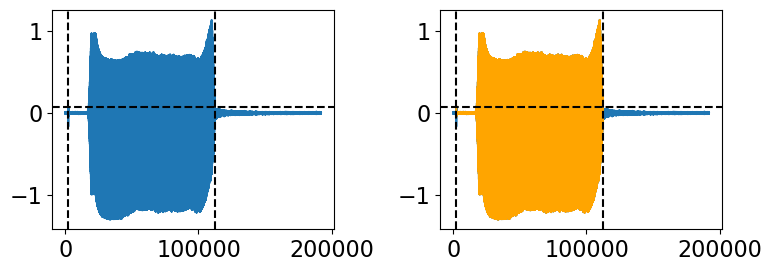

array([[-1.53412584,  0.27460297,  0.47703363]])

In [25]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 3, 27, 400000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

highpassed_audio_segments = dict()
audio_segments = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
        audio_segments[wav_AUDIOMOTH] = audio_seg
        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg

template_highpassed_signal = highpassed_audio_segments['040']
fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

threshold = 0.075
first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

ax = ax_all[0]
ax.plot(template_highpassed_signal)
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

ax = ax_all[1]
ax.plot(template_highpassed_signal)
ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

fig.tight_layout()
plt.show()

time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_dictionary = dict()
time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_highpassed_dictionary = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():

        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        num_samples = int(read_duration_in_secs*SAMPLERATE)
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(num_samples)

        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        signal1 = highpassed_audio_seg
        signal2 = relevant_template_highpassed_signal
        cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
        lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
        time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed
        
t_delay_ref_to_selected_channel = time_delay_in_seconds_highpassed_dictionary['040']
time_delay_mics_to_selected_ref_channel_temp = np.array([time_delay_in_seconds_highpassed_dictionary['014'],
                                                         time_delay_in_seconds_highpassed_dictionary['015'],
                                                         time_delay_in_seconds_highpassed_dictionary['040']])
time_delay_mics_to_selected_ref_channel = (time_delay_mics_to_selected_ref_channel_temp) - (t_delay_ref_to_selected_channel)

time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
num_noise = 1000

A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

source_locs = xs[:,0].reshape((1,3))
source_locs

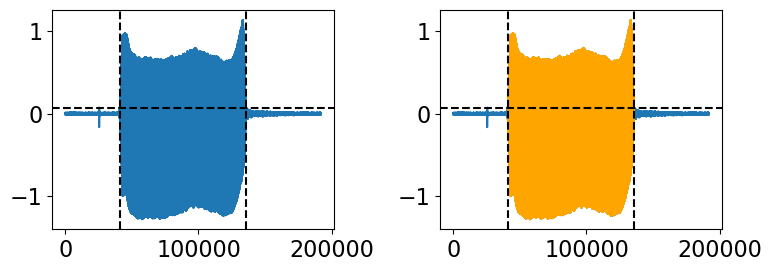

array([[-1.59993524,  0.20768061,  0.34501812]])

In [24]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 4, 27, 800000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

highpassed_audio_segments = dict()
audio_segments = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
        audio_segments[wav_AUDIOMOTH] = audio_seg
        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg

template_highpassed_signal = highpassed_audio_segments['040']
fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

threshold = 0.075
first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

ax = ax_all[0]
ax.plot(template_highpassed_signal)
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

ax = ax_all[1]
ax.plot(template_highpassed_signal)
ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

fig.tight_layout()
plt.show()

time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_dictionary = dict()
time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_highpassed_dictionary = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():

        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        num_samples = int(read_duration_in_secs*SAMPLERATE)
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(num_samples)

        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        signal1 = highpassed_audio_seg
        signal2 = relevant_template_highpassed_signal
        cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
        lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
        time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed
        
t_delay_ref_to_selected_channel = time_delay_in_seconds_highpassed_dictionary['040']
time_delay_mics_to_selected_ref_channel_temp = np.array([time_delay_in_seconds_highpassed_dictionary['014'],
                                                         time_delay_in_seconds_highpassed_dictionary['015'],
                                                         time_delay_in_seconds_highpassed_dictionary['040']])
time_delay_mics_to_selected_ref_channel = (time_delay_mics_to_selected_ref_channel_temp) - (t_delay_ref_to_selected_channel)

time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
num_noise = 1000

A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

source_locs = xs[:,0].reshape((1,3))
source_locs

In [29]:
recording_start_dt_values = list(pd.date_range(dt.datetime(2026, 6, 4, 19, 2, 57), dt.datetime(2026, 6, 4, 19, 4, 57), freq='30S'))
recording_start_dt_values

[Timestamp('2026-06-04 19:02:57'),
 Timestamp('2026-06-04 19:03:27'),
 Timestamp('2026-06-04 19:03:57'),
 Timestamp('2026-06-04 19:04:27'),
 Timestamp('2026-06-04 19:04:57')]

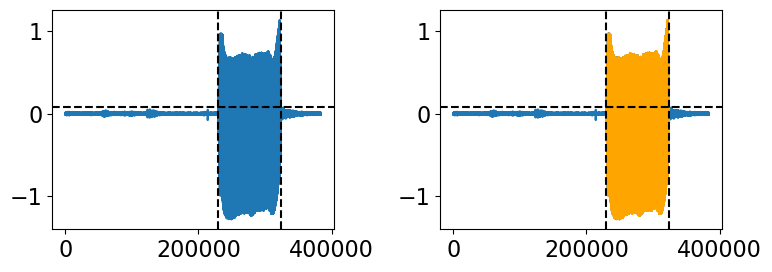

Playback at 12:02:57 localized to [[-0.86059183  0.34085643  0.47811622]]


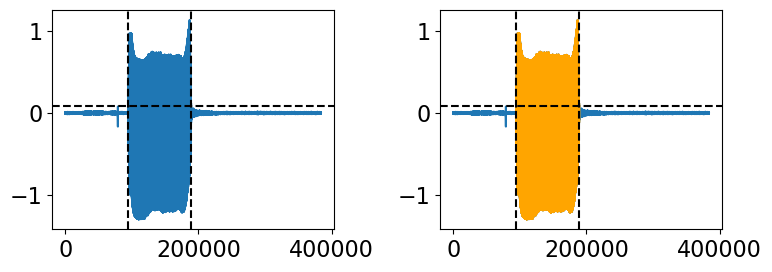

Playback at 12:03:27 localized to [[-1.53412584  0.27460297  0.47703363]]


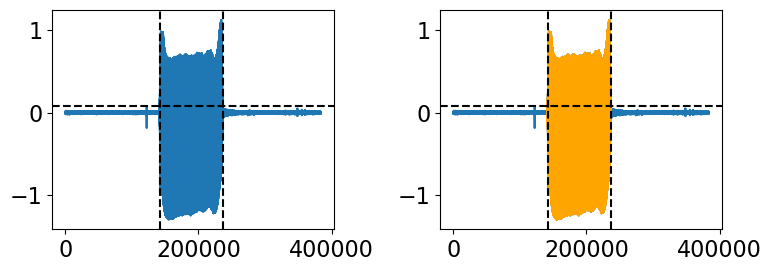

Playback at 12:03:57 localized to [[-1.780384    0.24590233  0.44855167]]


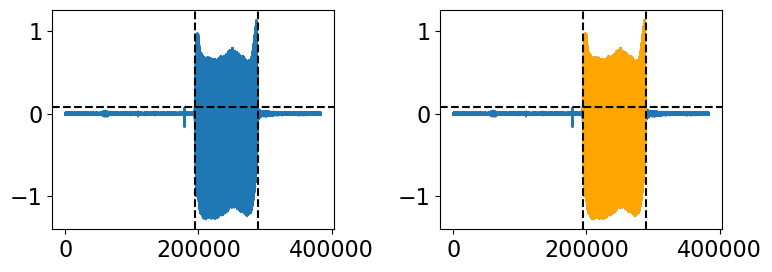

Playback at 12:04:27 localized to [[-1.59993524  0.20768061  0.34501812]]


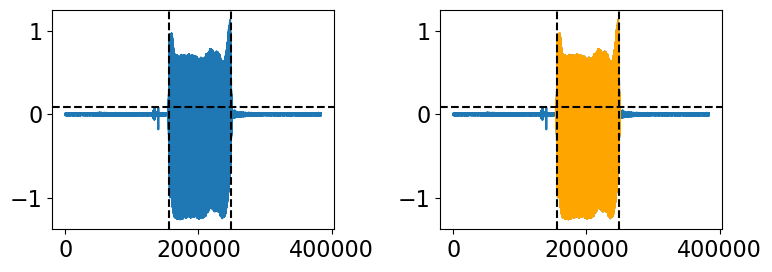

Playback at 12:04:57 localized to [[-2.71323066  0.18711124  0.32999323]]


In [34]:
all_playbacks_source_locs = np.zeros((len(recording_start_dt_values), 3))
for i, recording_start_dt in enumerate(recording_start_dt_values):
    recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
    SAMPLERATE = 192000

    highpassed_audio_segments = dict()
    audio_segments = dict()
    for example_wav_file in valid_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
            example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
            samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
            recorded_audio = sf.SoundFile(example_wav_file)
            read_offset = samples_until_recording_start
            read_duration_in_secs = 2
            recorded_audio.seek(int(SAMPLERATE*read_offset))
            audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
            audio_segments[wav_AUDIOMOTH] = audio_seg
            highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
            highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg

    template_highpassed_signal = highpassed_audio_segments['040']
    fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

    threshold = 0.085
    first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
    last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
    relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

    ax = ax_all[0]
    ax.plot(template_highpassed_signal)
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

    ax = ax_all[1]
    ax.plot(template_highpassed_signal)
    ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

    fig.tight_layout()
    plt.show()

    time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
    time_delay_in_seconds_dictionary = dict()
    time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
    time_delay_in_seconds_highpassed_dictionary = dict()
    for example_wav_file in valid_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():

            example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
            samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
            recorded_audio = sf.SoundFile(example_wav_file)
            read_offset = samples_until_recording_start
            read_duration_in_secs = 2
            num_samples = int(read_duration_in_secs*SAMPLERATE)
            recorded_audio.seek(int(SAMPLERATE*read_offset))
            audio_seg = recorded_audio.read(num_samples)

            highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
            signal1 = highpassed_audio_seg
            signal2 = relevant_template_highpassed_signal
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
            time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed
            
    t_delay_ref_to_selected_channel = time_delay_in_seconds_highpassed_dictionary['040']
    time_delay_mics_to_selected_ref_channel_temp = np.array([time_delay_in_seconds_highpassed_dictionary['014'],
                                                            time_delay_in_seconds_highpassed_dictionary['015'],
                                                            time_delay_in_seconds_highpassed_dictionary['040']])
    time_delay_mics_to_selected_ref_channel = (time_delay_mics_to_selected_ref_channel_temp) - (t_delay_ref_to_selected_channel)

    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
    num_noise = 1000

    A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
    wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
    xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

    source_locs = xs[:,0].reshape((1,3))
    print(f"Playback at {recording_start_string} localized to {source_locs}")
    all_playbacks_source_locs[i] = source_locs

In [35]:
UBNA_ARRAY_MIC_LOCS = np.vstack([A_locs_mat_tdoa_meters, ref_A_loc_meters])
UBNA_ARRAY_MIC_LOCS

array([[-1.9973214 , 69.68215403],
       [ 1.24832974, 33.72912775],
       [ 0.        ,  0.        ]])

In [36]:
all_playbacks_source_locs

array([[-0.86059183,  0.34085643,  0.47811622],
       [-1.53412584,  0.27460297,  0.47703363],
       [-1.780384  ,  0.24590233,  0.44855167],
       [-1.59993524,  0.20768061,  0.34501812],
       [-2.71323066,  0.18711124,  0.32999323]])

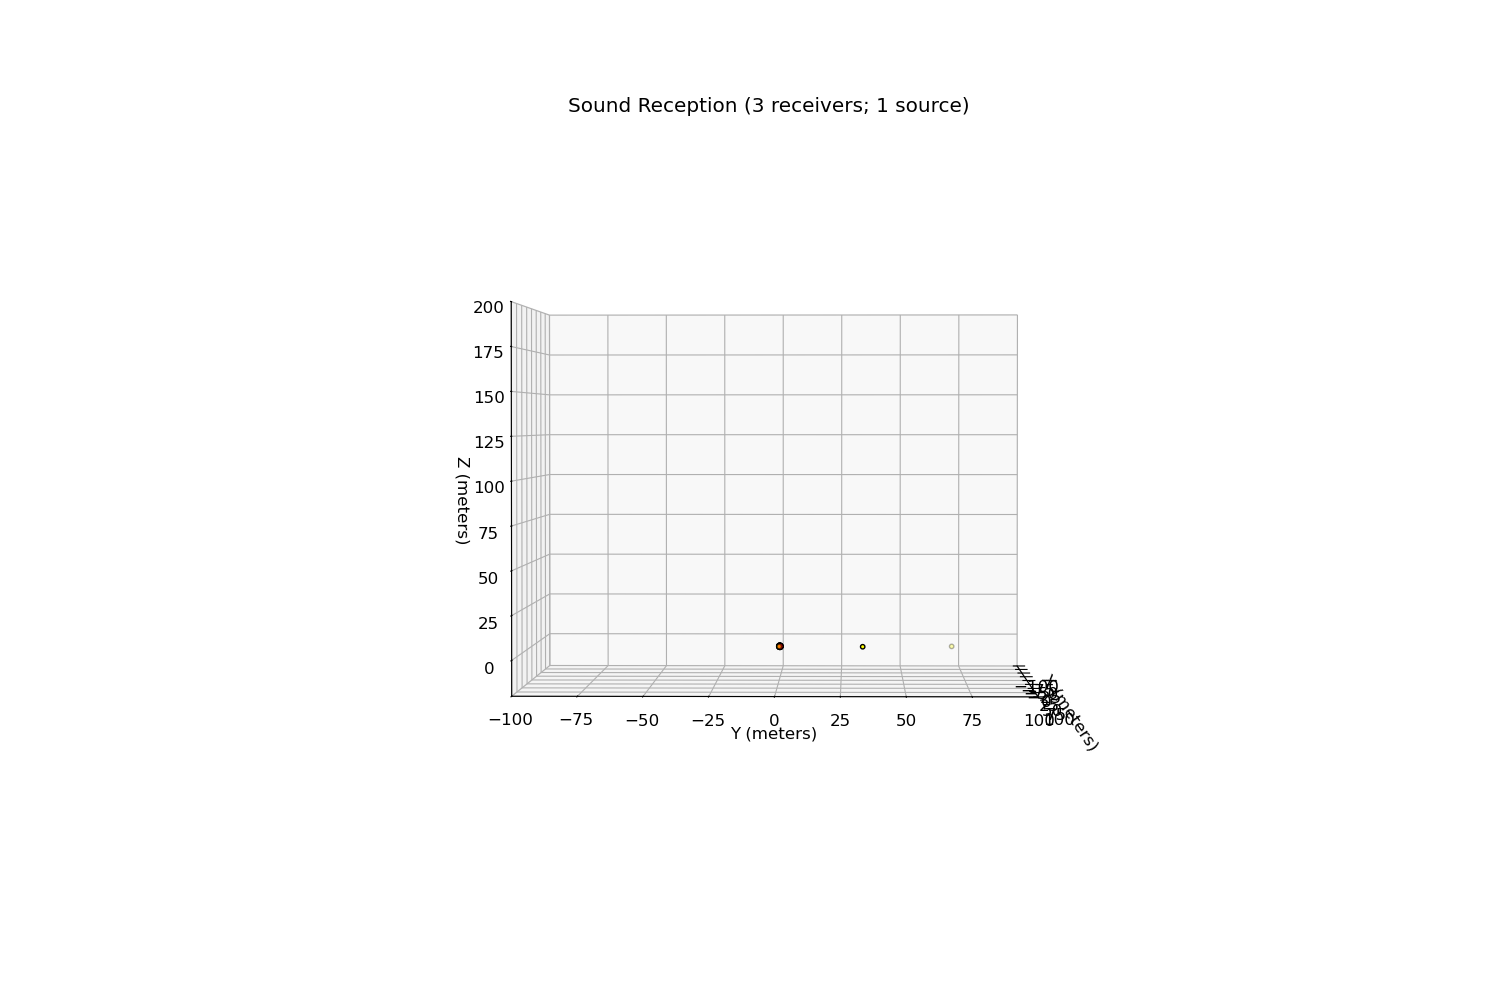

In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib widget
fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
map_ax_3d = fig.add_subplot(projection='3d')
POINT_SIZE = 40
GRID_SIZE = 200
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
# rN_z = UBNA_ARRAY_MIC_LOCS[:,2]

map_ax_3d.scatter(rN_x, rN_y, 0, s=10, color='yellow', edgecolor='k', zorder=1)
map_ax_3d.scatter(all_playbacks_source_locs[:,0], 
                  all_playbacks_source_locs[:,1], 0, color='r', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS+1)} receivers; 1 source)")
map_ax_3d.view_init(elev=1, azim=1)

plt.show()